# BINF 4211: Applied Data Mining for Bioinformatics.
## Lab: UMAP

This notebook is designed for learning **UMAP (Uniform Manifold Approximation and Projection)** in

## Learning goals
By the end of this notebook, students should be able to:

1. Explain the main idea of UMAP at an intuitive level.
2. Apply UMAP to both synthetic and real datasets.
3. Interpret the meaning and limits of a UMAP embedding.
4. Understand the role of key hyperparameters such as:
   - `n_neighbors`
   - `min_dist`
   - distance `metric`
5. Use UMAP responsibly in exploratory data analysis.

## Recommended background
Students should already know:
- what a feature vector is
- Euclidean distance
- nearest neighbors
- the idea of dimensionality reduction
- basic Python, NumPy, pandas, and scikit-learn

# 1. Big-picture intuition

UMAP is a **nonlinear dimensionality reduction** method. It takes data that live in a high-dimensional space and produces a low-dimensional representation, often in 2D, so that we can visualize patterns.

A useful intuition is:

- In high dimensions, each sample has a set of **nearby neighbors**.
- UMAP tries to preserve this neighborhood structure in a low-dimensional map.
- Points that were close in the original space should often remain close in the embedding.
- At the same time, UMAP tries to organize the embedding into a compact and useful geometric layout.

UMAP is often used for:
- exploratory data analysis
- clustering visualization
- single-cell omics visualization
- image and text embeddings
- detecting possible subgroups or trajectories

## Important caution
A 2D UMAP plot is a **representation**, not the truth itself.

You should be cautious about over-interpreting:
- exact distances between far-apart clusters
- cluster size or area
- the apparent emptiness of regions
- whether two groups are "truly separate" biologically or statistically

UMAP is excellent for exploration, but interpretation should be checked against the original data and domain knowledge.

# 2. Conceptual sketch of how UMAP works

Without going deeply into the full mathematics, the basic workflow is:

1. For each point, identify nearby neighbors in the original high-dimensional space.
2. Build a weighted graph representing local neighborhood relationships.
3. Find a low-dimensional arrangement of points whose neighborhood relationships are similar.
4. Optimize the layout so that nearby points attract each other and unrelated points are discouraged from collapsing together.

You can think of UMAP as trying to answer:

> "Can I draw these points in 2D so that the local neighborhood structure still makes sense?"

## Two key hyperparameters

### `n_neighbors`
Controls how much local versus broader structure UMAP emphasizes.

- Smaller `n_neighbors`:
  - focuses more on very local structure
  - can reveal fine subclusters
  - may fragment the data more

- Larger `n_neighbors`:
  - uses a broader neighborhood notion
  - tends to preserve more global organization
  - can smooth away very small local details

### `min_dist`
Controls how tightly points are allowed to pack together in the embedding.

- Smaller `min_dist`:
  - clusters can become tighter and denser
  - often visually sharper separation

- Larger `min_dist`:
  - points spread out more
  - local clusters look looser

These parameters affect the visualization a lot, so one plot should not be treated as the only valid picture of the data.

In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

# UMAP may be installed either as umap-learn or importable as umap
try:
    import umap
    import umap.umap_ as umap_module
except Exception as e:
    raise ImportError(
        "UMAP is not installed. Install it with: pip install umap-learn"
    ) from e

# For reproducibility in this notebook
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. A helper function for plotting embeddings

In [2]:
def plot_embedding(X_embedded, y=None, title="Embedding", cmap="tab10", alpha=0.8):
    plt.figure(figsize=(7, 5))
    if y is None:
        plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=25, alpha=alpha)
    else:
        scatter = plt.scatter(
            X_embedded[:, 0],
            X_embedded[:, 1],
            c=y,
            s=25,
            alpha=alpha,
            cmap=cmap
        )
        plt.colorbar(scatter, label="Class / group")
    plt.title(title, fontsize=13)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.show()

# 4. First example: a simple synthetic dataset

We start with a synthetic dataset because it is easier to teach from data whose structure we understand.

Below we create several Gaussian blobs in a higher-dimensional space, standardize the features, and then apply UMAP.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Original shape: (600, 10)
UMAP embedding shape: (600, 2)


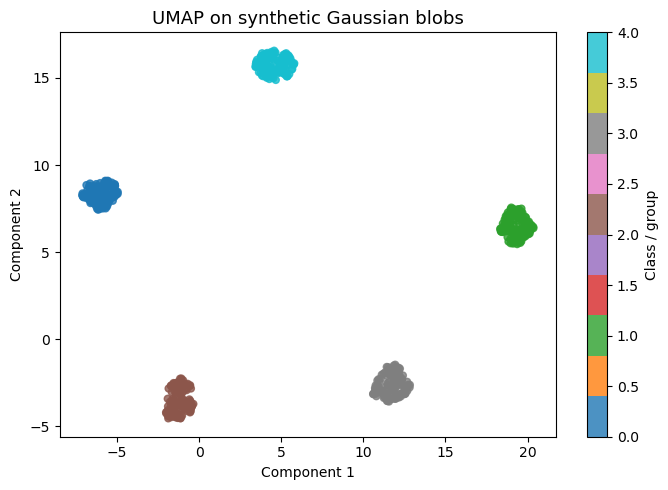

In [3]:
# Synthetic dataset: multiple clusters in 10 dimensions
X_blobs, y_blobs = make_blobs(
    n_samples=600,
    centers=5,
    n_features=10,
    cluster_std=2.2,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE
)

X_blobs_umap = reducer.fit_transform(X_blobs_scaled)

print("Original shape:", X_blobs_scaled.shape)
print("UMAP embedding shape:", X_blobs_umap.shape)

plot_embedding(
    X_blobs_umap,
    y_blobs,
    title="UMAP on synthetic Gaussian blobs"
)

## Discussion

Questions:

1. Do the clusters appear well separated?
2. Does this mean the original 10-dimensional data were perfectly separated?
3. If two clusters are far apart in the UMAP plot, can we conclude their original high-dimensional distance is exactly reflected here?

### Teaching point
UMAP can often reveal cluster structure clearly, but the **2D geometry is not a literal map** of all original distances.

# 5. Second example: nonlinear structure with two moons

A classic reason to use nonlinear dimensionality reduction is that the data may follow curved or manifold-like structure.

The `make_moons` dataset has a nonlinear arrangement that is not well described by a single straight subspace.

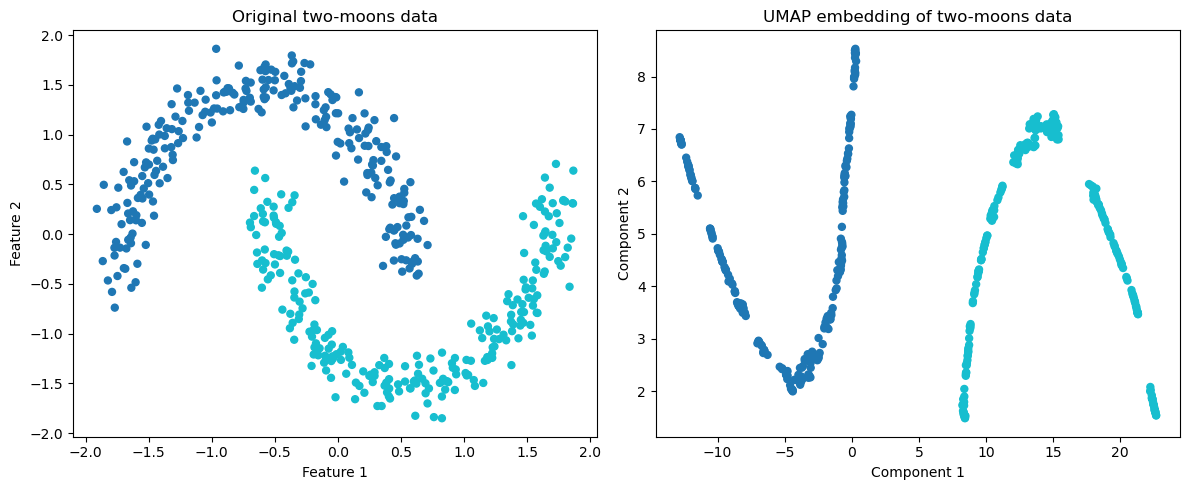

In [8]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=RANDOM_STATE)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

moon_reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="euclidean",
    random_state=RANDOM_STATE
)

X_moons_umap = moon_reducer.fit_transform(X_moons_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=y_moons, s=25, cmap="tab10")
plt.title("Original two-moons data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.scatter(X_moons_umap[:, 0], X_moons_umap[:, 1], c=y_moons, s=25, cmap="tab10")
plt.title("UMAP embedding of two-moons data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.tight_layout()
plt.show()

## Discussion

Here, the original data are already 2D, so why apply UMAP at all?

This is a good teaching example because it shows that UMAP is not just about reducing from very high dimensions. It is about **re-representing data according to neighborhood structure**.

In real applications, UMAP is much more often used when the original data may have:
- tens of features
- hundreds of features
- thousands of features

# 6. Real dataset example: Wine dataset

Now we move to a real labeled dataset from scikit-learn. The wine dataset has chemical measurements for wines from three classes.

This is a nice teaching dataset because:
- it has multiple numeric features
- class labels are known
- the dimensionality is moderate
- it is easy to visualize

Wine data shape: (178, 13)
Number of classes: 3


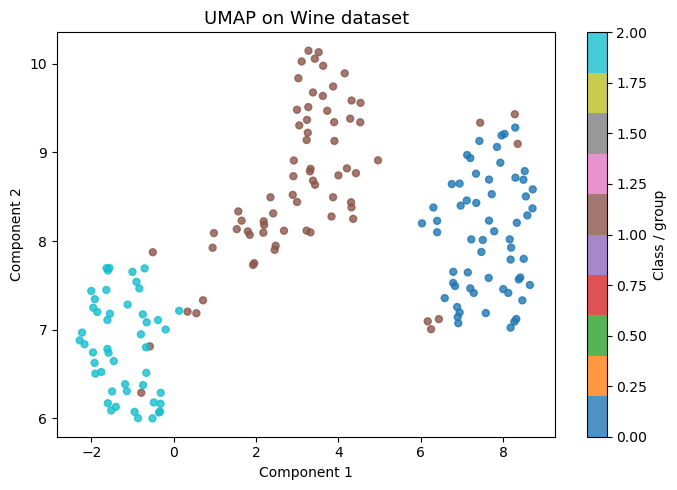

In [9]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names

print("Wine data shape:", X_wine.shape)
print("Number of classes:", len(np.unique(y_wine)))

X_wine_scaled = StandardScaler().fit_transform(X_wine)

wine_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE
)

X_wine_umap = wine_reducer.fit_transform(X_wine_scaled)

plot_embedding(
    X_wine_umap,
    y_wine,
    title="UMAP on Wine dataset"
)

## Discussion

Questions:

1. Do the three wine classes appear separated?
2. Are all classes equally compact?
3. If one class spreads out more in the embedding, what might that mean?

Possible interpretations:
- that class may have more internal heterogeneity
- the chosen hyperparameters may be affecting the visual spread
- the 2D projection may compress some directions more than others

# 7. Effect of `n_neighbors`

Now we keep the data fixed and change `n_neighbors`.

This is one of the most important classroom demonstrations because we will quickly see that **UMAP does not give one unique picture** independent of parameter choices.

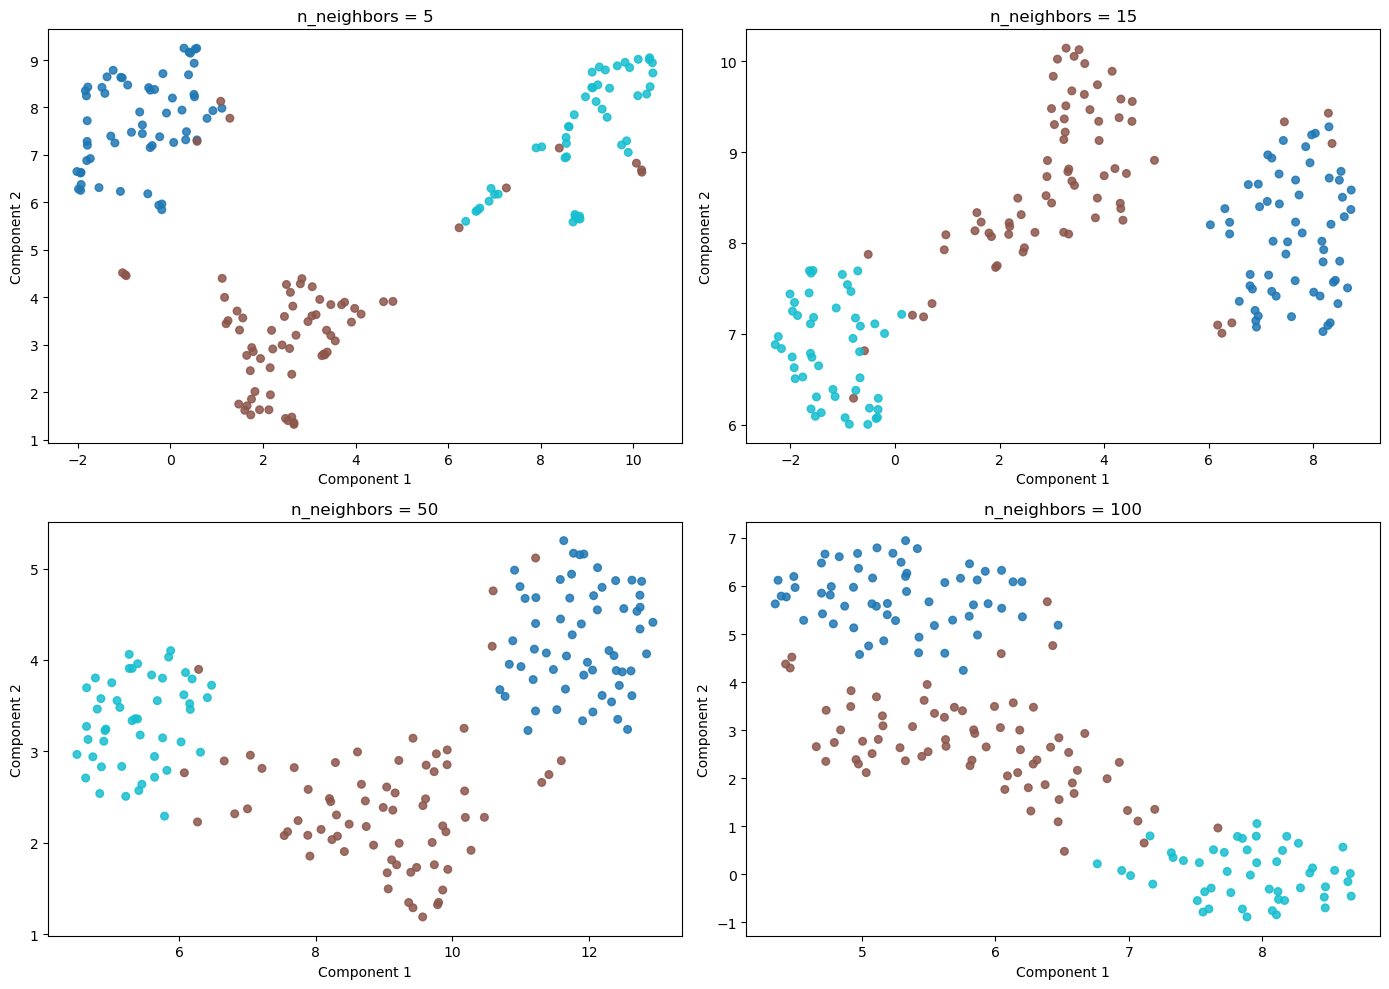

In [10]:
neighbor_values = [5, 15, 50, 100]

plt.figure(figsize=(14, 10))

for i, n_neighbors in enumerate(neighbor_values, start=1):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=0.1,
        metric="euclidean",
        random_state=RANDOM_STATE
    )
    X_embedded = reducer.fit_transform(X_wine_scaled)

    plt.subplot(2, 2, i)
    plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y_wine,
        s=30,
        cmap="tab10",
        alpha=0.85
    )
    plt.title(f"n_neighbors = {n_neighbors}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

plt.tight_layout()
plt.show()

## Interpretation

### Smaller `n_neighbors`
UMAP emphasizes very local relationships.
This can make small neighborhoods stand out strongly.

### Larger `n_neighbors`
UMAP takes a broader view of the data structure.
This may reduce fragmentation and produce smoother organization.

## Discussion prompt
Which plot would you trust most?

A strong answer is:
> None should be trusted blindly. We compare several settings and look for patterns that are stable across settings.

# 8. Effect of `min_dist`

Next we vary `min_dist` while keeping the rest fixed.

This parameter affects how compressed or spread out the embedding appears.

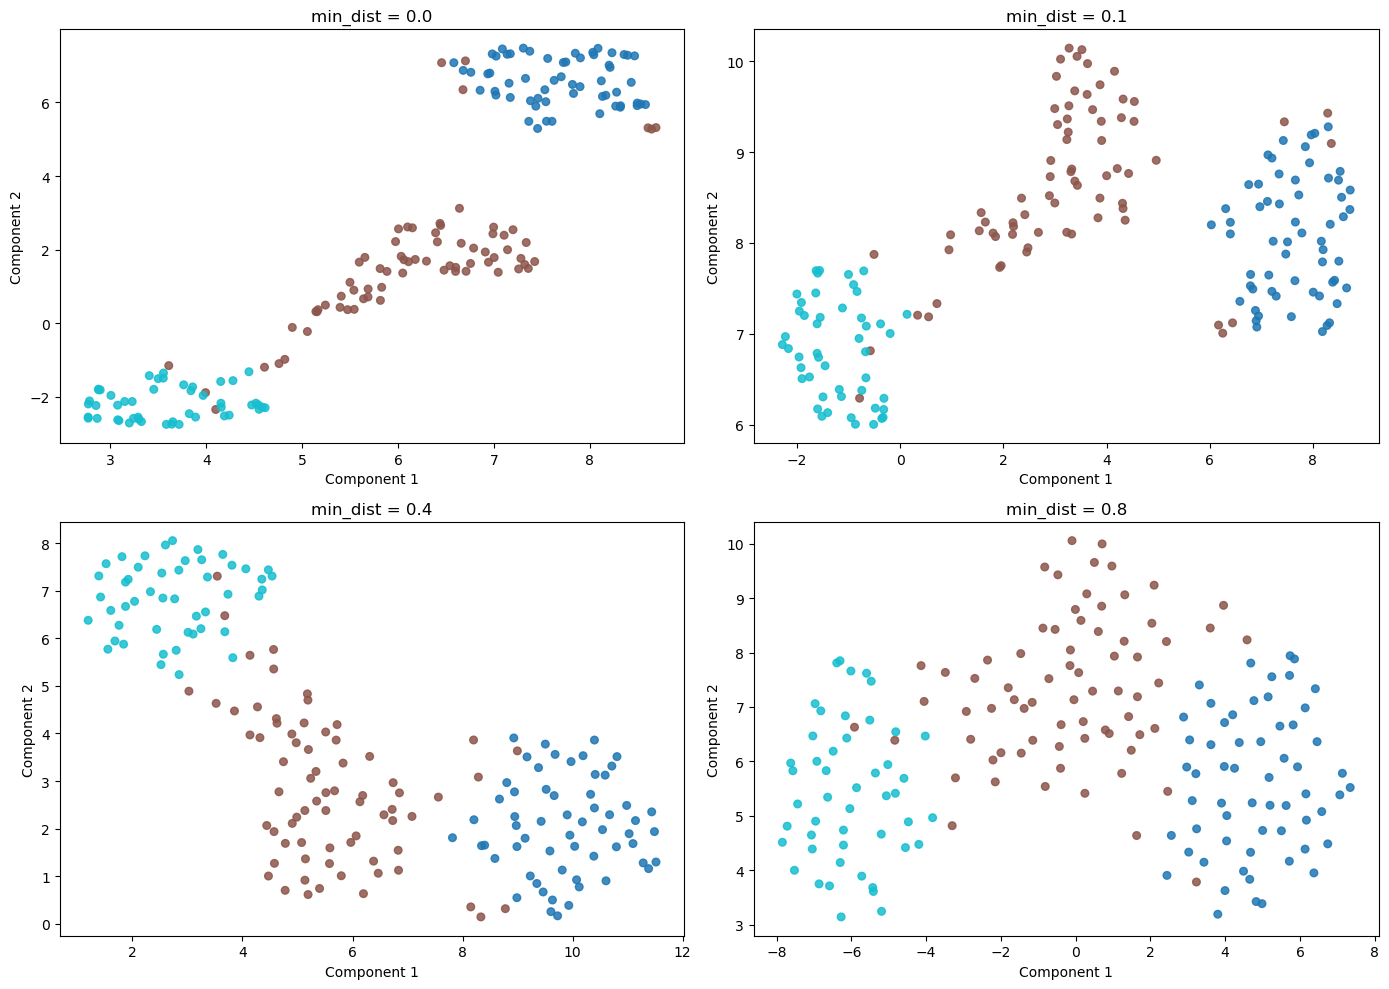

In [11]:
min_dist_values = [0.0, 0.1, 0.4, 0.8]

plt.figure(figsize=(14, 10))

for i, min_dist in enumerate(min_dist_values, start=1):
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=min_dist,
        metric="euclidean",
        random_state=RANDOM_STATE
    )
    X_embedded = reducer.fit_transform(X_wine_scaled)

    plt.subplot(2, 2, i)
    plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y_wine,
        s=30,
        cmap="tab10",
        alpha=0.85
    )
    plt.title(f"min_dist = {min_dist}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

plt.tight_layout()
plt.show()

## Interpretation

- Smaller `min_dist` often produces tighter-looking clusters.
- Larger `min_dist` often yields more diffuse point clouds.

## Important caution
A tighter cluster in the plot does **not automatically** mean the class is inherently more homogeneous in the original space.
It may partly reflect the embedding settings.

# 9. Effect of distance metric

UMAP can use different distance metrics. This can matter a great deal depending on the data type.

Examples:
- `euclidean`: common default for continuous numeric data
- `manhattan`: sometimes useful for certain feature spaces
- `cosine`: often useful for sparse vectors, embeddings, or text-like representations

Here we compare a few metrics on the wine dataset.

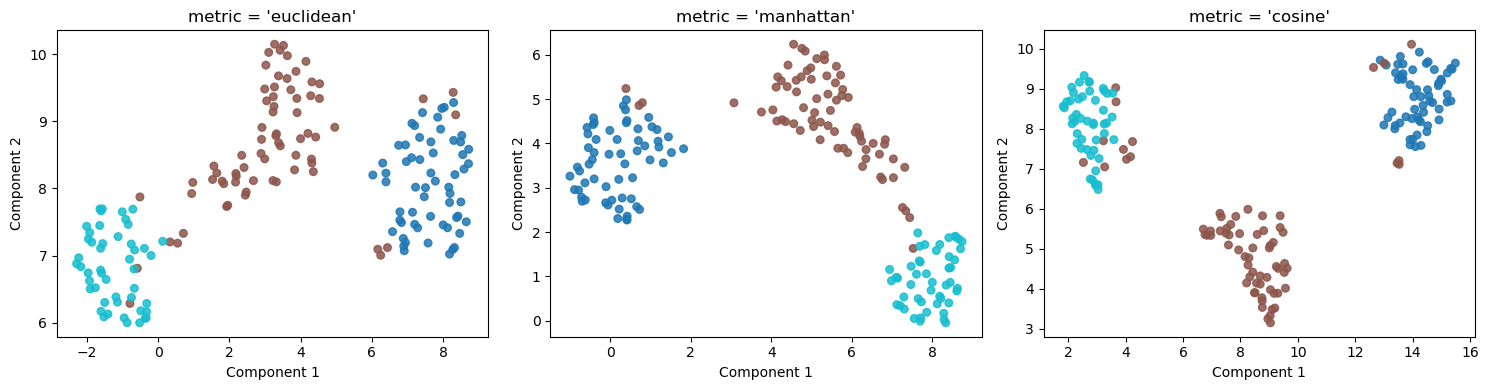

In [12]:
metrics = ["euclidean", "manhattan", "cosine"]

plt.figure(figsize=(15, 4))

for i, metric in enumerate(metrics, start=1):
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric=metric,
        random_state=RANDOM_STATE
    )
    X_embedded = reducer.fit_transform(X_wine_scaled)

    plt.subplot(1, 3, i)
    plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y_wine,
        s=30,
        cmap="tab10",
        alpha=0.85
    )
    plt.title(f"metric = '{metric}'")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

plt.tight_layout()
plt.show()

## Discussion

Why might the metric matter?

Because "who is close to whom" depends on how we define distance.
Since UMAP is built around neighborhood structure, the distance metric can substantially change the graph it constructs.

# 10. Reproducibility and random seed

UMAP contains stochastic elements. That means different random seeds can produce somewhat different embeddings.

So:
- the exact picture may vary
- stable patterns across runs are more convincing than features seen in only one run

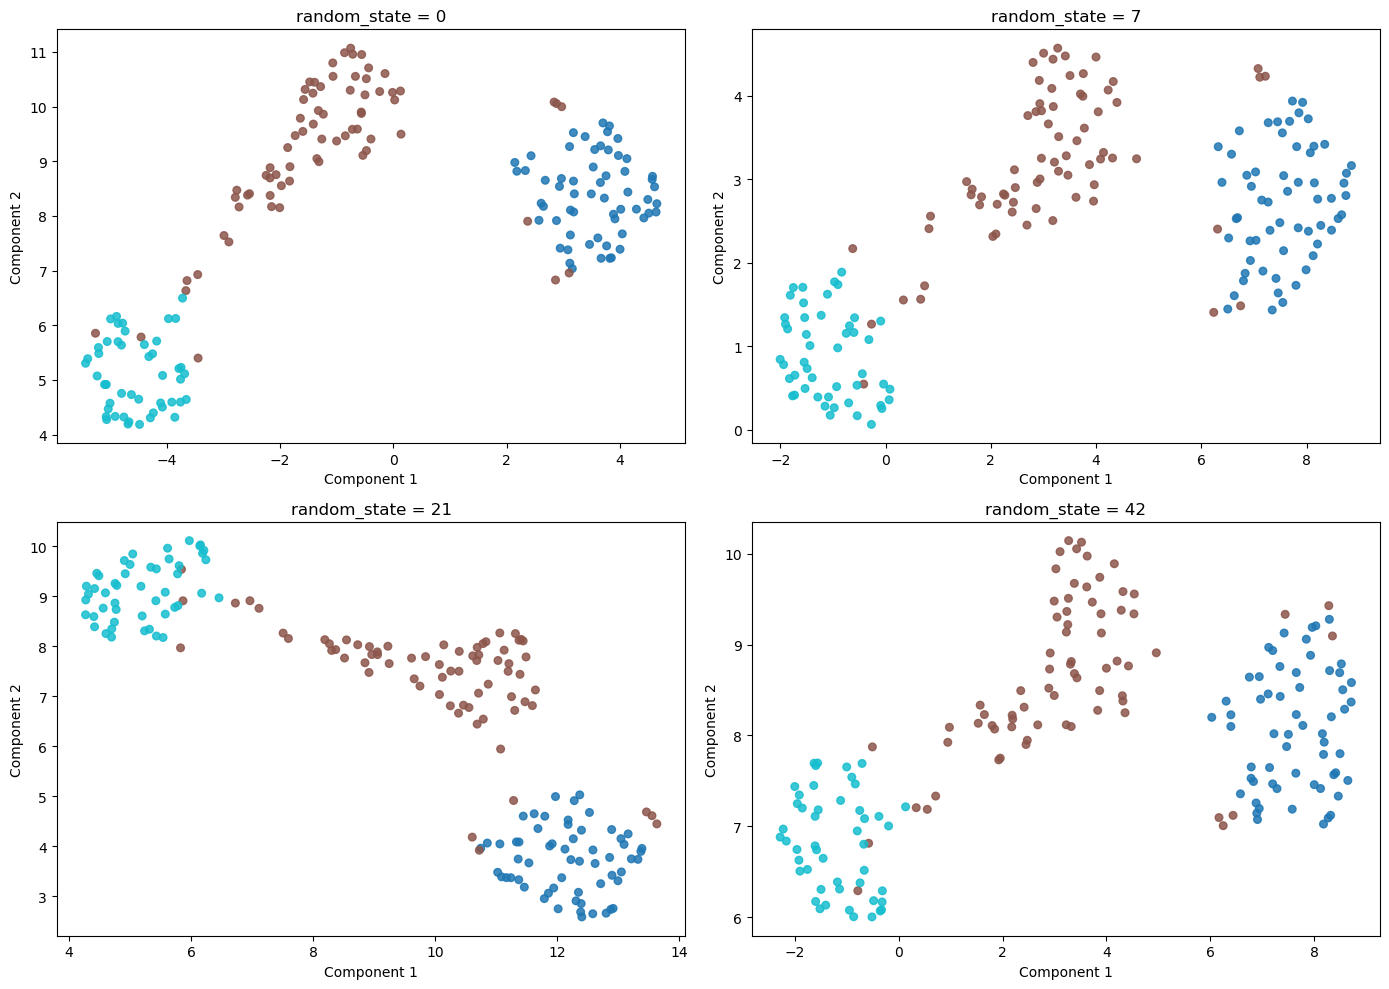

In [13]:
seeds = [0, 7, 21, 42]

plt.figure(figsize=(14, 10))

for i, seed in enumerate(seeds, start=1):
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=seed
    )
    X_embedded = reducer.fit_transform(X_wine_scaled)

    plt.subplot(2, 2, i)
    plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y_wine,
        s=30,
        cmap="tab10",
        alpha=0.85
    )
    plt.title(f"random_state = {seed}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

plt.tight_layout()
plt.show()

## Interpretation

Even if the plots are not identical, ask:

- Are the same broad groups present?
- Are certain relationships stable across runs?
- Which patterns are robust?

This is a better scientific mindset than treating one embedding as definitive.

# 11. Higher-dimensional real data example: Digits dataset

The digits dataset has 64 features per sample (8×8 image pixels). This provides a more realistic example of dimensionality reduction for visualization.

Digits data shape: (1797, 64)


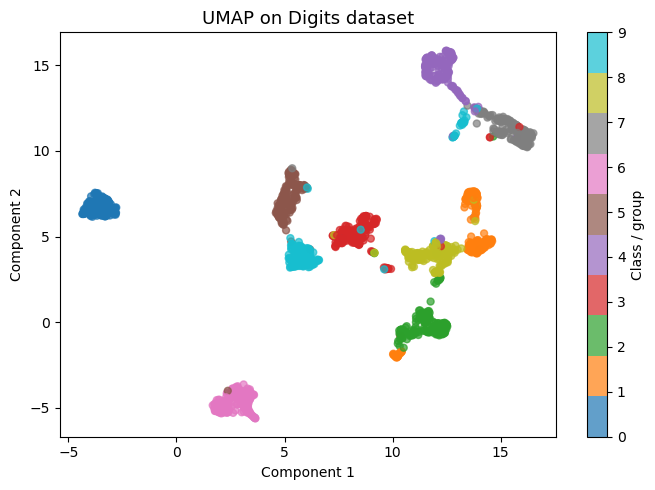

In [14]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("Digits data shape:", X_digits.shape)

X_digits_scaled = StandardScaler().fit_transform(X_digits)

digits_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE
)

X_digits_umap = digits_reducer.fit_transform(X_digits_scaled)

plot_embedding(
    X_digits_umap,
    y_digits,
    title="UMAP on Digits dataset",
    cmap="tab10",
    alpha=0.7
)

## Discussion questions

1. Do some digits form cleaner groups than others?
2. Which digits seem to overlap?
3. If two digit groups overlap in the embedding, what might that indicate?

Possible answers:
- some digit classes are visually similar
- some classes may be harder to separate in the original feature space
- the chosen embedding parameters may not perfectly separate all classes

# 12. A simple classroom workflow for applying UMAP

A practical workflow for students is:

1. **Prepare the data**
   - numeric matrix of shape `(n_samples, n_features)`
   - handle missing values
   - scale features when appropriate

2. **Choose a metric**
   - Euclidean for many continuous datasets
   - Cosine for some embedding-like or sparse datasets

3. **Try baseline settings**
   - `n_neighbors=15`
   - `min_dist=0.1`
   - `random_state=42`

4. **Vary parameters**
   - compare several `n_neighbors`
   - compare several `min_dist`
   - possibly compare multiple metrics

5. **Interpret cautiously**
   - look for patterns stable across settings
   - do not over-claim biological or mechanistic meaning from the picture alone

6. **Validate with other analyses**
   - clustering
   - class labels
   - marker variables
   - statistical testing
   - domain knowledge

# 13. Common mistakes when using UMAP

## Mistake 1: Treating 2D distance as exact original distance
UMAP preserves neighborhood structure better than exact all-pairs geometry.

## Mistake 2: Assuming cluster area or shape is intrinsically meaningful
The visual shape of a cluster may depend strongly on the embedding algorithm and hyperparameters.

## Mistake 3: Using unscaled data without thinking
If features are on very different scales, the neighborhood structure may be dominated by large-scale variables.

## Mistake 4: Showing only one parameter setting
A more responsible approach is to compare multiple settings.

## Mistake 5: Claiming discovery from visualization alone
UMAP is exploratory. Strong claims require additional evidence.

# 14. Student exercise

## Exercise A
Apply UMAP to the wine dataset using:
- `n_neighbors=5, 15, 50`
- `min_dist=0.0, 0.1, 0.5`

Write 3 to 5 sentences describing what changes.

## Exercise B
Apply UMAP to the digits dataset using:
- metric = `euclidean`
- metric = `cosine`

Which classes appear more or less separated under the two metrics?

## Exercise C
Run UMAP with three different random seeds on the same dataset.
Which patterns are stable?
Which are not?

## Exercise D
Choose your own dataset and justify:
- why you scaled or did not scale
- which metric you chose
- which parameter settings you tried
- what conclusions are safe versus unsafe

# 15. Reusable template for student projects

In [ ]:
# ===========================
# Reusable UMAP template
# ===========================

# Replace X and y with your own dataset
# X should be a numeric matrix of shape (n_samples, n_features)
# y is optional, used only for coloring

# Example:
# X = your_dataframe.values
# y = your_labels

from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt

# Step 1: scale if appropriate
X_scaled = StandardScaler().fit_transform(X)

# Step 2: fit UMAP
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

# Step 3: visualize
plt.figure(figsize=(7, 5))
if 'y' in globals() and y is not None:
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, s=25, cmap="tab10", alpha=0.8)
    plt.colorbar()
else:
    plt.scatter(X_umap[:, 0], X_umap[:, 1], s=25, alpha=0.8)

plt.title("UMAP embedding")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

# 16. Summary

UMAP is a powerful tool for visualizing high-dimensional data, especially when local neighborhood structure matters.

## Main takeaways
- UMAP is a **nonlinear** dimensionality reduction method.
- It is strongly influenced by **neighborhood structure**.
- Key parameters include:
  - `n_neighbors`
  - `min_dist`
  - `metric`
- Results can vary with parameter settings and random seed.
- UMAP is best used for **exploration**, not as sole proof of scientific conclusions.

## One-sentence summary
UMAP helps us create a low-dimensional map that preserves meaningful local relationships, but that map must be interpreted carefully.

# 17. Optional extension for bioinformatics

In bioinformatics, UMAP is especially common in:
- single-cell RNA-seq
- proteomics embeddings
- metabolomics feature representations
- microbiome profiles
- patient stratification

When using UMAP in bioinformatics, remember:
- preprocessing choices matter enormously
- scaling and normalization matter
- batch effects can dominate the embedding
- a visually separated cluster is not automatically a biologically meaningful cell type or subtype

This makes UMAP a very useful exploratory tool, but one that must be paired with careful validation.